# ID11 diffraction-map filtering and export

This notebook provides one clean workflow for **unbinned pixels** and **2×2 spatially binned pixels**:

1. Load saved ROI `.npz` files.
2. Explore the intensity map and inspect individual or rectangularly averaged 1D patterns.
3. Flag low-intensity scanning points using the intensity integrated over the full \(2\theta\) range.
4. Save validated `.npz` files, with invalid patterns replaced by `NaN`.
5. Export only valid patterns as headerless two-column `.xy` files.
6. Calculate one filtered average pattern **separately for each ROI**.

## Principle

The stored diffraction array is expected to have the axis order

\[
I(2\theta,\;r,\;c)
\]

with shape:

```text
(number of 2θ points, number of rows, number of columns)
```

For every scanning point, the validation metric is

\[
S(r,c)=\sum_{2\theta} I(2\theta,r,c).
\]

A point is marked invalid when:

```text
S(r, c) <= threshold
```

or when its data are not finite. The complete 1D pattern of an invalid point is replaced by `NaN`. Invalid points are not exported to `.xy`.

For spatial binning, each \(2\times2\) block is combined independently at every \(2\theta\) value. With `BIN_OPERATION = "mean"`, the four patterns are averaged. With `"sum"`, their counts are added.

## Settings to change

Edit only the configuration cell below for normal use.

- `ROI_FOLDER`: folder containing the original ROI `.npz` files.
- `BIN_SIZE`: spatial bin size. The current workflow is designed for `2`.
- `BIN_OPERATION`: `"mean"` or `"sum"`.
  - `"mean"` keeps the binned intensity scale comparable to one original pixel.
  - `"sum"` adds the counts, so the threshold will usually be larger.
- `INITIAL_THRESHOLD_PERCENTILE`: only the initial threshold suggestion. The final threshold is selected interactively.
- `XY_PREFIX`: prefix used for exported pattern filenames.
- `XY_FORMAT`: numeric format of the headerless `.xy` files.

The threshold chosen in a validator is applied to **all ROI files** when its save button is pressed.

In [9]:
# Configuration and imports

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle
from matplotlib.widgets import RectangleSelector

from ipywidgets import (
    Button,
    Checkbox,
    Dropdown,
    FloatLogSlider,
    HTML,
    HBox,
    ToggleButtons,
    VBox,
)
from IPython.display import display

%matplotlib widget

# -------------------------- main inputs --------------------------

ROI_FOLDER = Path("/home/esrf/tran/pigment")
ROI_PATTERN = "*.npz"

BIN_SIZE = 2
BIN_OPERATION = "mean"           # "mean" or "sum"

INITIAL_THRESHOLD_PERCENTILE = 1.0

XY_PREFIX = "pap"
XY_FORMAT = "%.8e"

# -------------------------- output folders -----------------------

VALIDATED_FOLDERS = {
    "unbinned": ROI_FOLDER / "validated_unbinned_npz_id11",
    "binned": ROI_FOLDER / "validated_binned_npz_id11",
}

XY_FOLDERS = {
    "unbinned": ROI_FOLDER / "validated_unbinned_xy_id11",
    "binned": ROI_FOLDER / "validated_binned_xy_id11",
}

AVERAGE_FOLDERS = {
    "unbinned": (
        ROI_FOLDER
        / "average_filtered_patterns_id11"
        / "per_roi_unbinned"
    ),
    "binned": (
        ROI_FOLDER
        / "average_filtered_patterns_id11"
        / "per_roi_binned"
    ),
}

## Reusable functions

Run the next cell once. It contains all shared loading, binning, validation, export, and averaging logic. The interactive cells below only call these functions, which avoids repeating the same code for unbinned and binned data.

In [10]:
def discover_roi_files():
    """Return the original ROI NPZ files in a stable order."""
    files = sorted(ROI_FOLDER.glob(ROI_PATTERN))

    if not files:
        raise FileNotFoundError(
            f"No ROI files matching {ROI_PATTERN!r} found in:\n"
            f"{ROI_FOLDER}"
        )

    return files


def scalar_text(value):
    """Convert a scalar NumPy value to normal text."""
    array = np.asarray(value)

    if array.ndim == 0:
        return str(array.item())

    return str(value)


def safe_tag(text):
    """Make a string safe for use in filenames."""
    text = scalar_text(text)
    tag = "".join(
        character
        if character.isalnum() or character in "-_"
        else "_"
        for character in text
    ).strip("_")

    return tag or "roi"


def full_theta_sum(intensity):
    """
    Integrate each spatial pattern over the full 2θ axis.

    All-NaN patterns remain NaN instead of becoming zero.
    """
    intensity = np.asarray(intensity)

    if intensity.ndim != 3:
        raise ValueError(
            "Expected intensity shape "
            "(two_theta, row, column), "
            f"found {intensity.shape}."
        )

    finite_any = np.any(
        np.isfinite(intensity),
        axis=0,
    )

    result = np.nansum(
        intensity,
        axis=0,
        dtype=np.float64,
    )

    result = np.asarray(
        result,
        dtype=np.float64,
    )

    result[~finite_any] = np.nan

    return result


def _index_vector(data, keys, length, start=0):
    """Load a one-dimensional index vector with a safe fallback."""
    for key in keys:
        if key in data:
            values = np.asarray(
                data[key],
                dtype=np.int32,
            ).reshape(-1)

            if len(values) == length:
                return values

    return np.arange(
        start,
        start + length,
        dtype=np.int32,
    )


def load_roi_file(filepath):
    """
    Load one original ROI file.

    Returned intensity always has shape:
    (two_theta, local_row, local_column)
    """
    filepath = Path(filepath)

    with np.load(
        filepath,
        allow_pickle=False,
    ) as data:

        intensity = np.asarray(
            data["intensity"],
            dtype=np.float32,
        )

        two_theta = np.asarray(
            data["two_theta"],
            dtype=np.float64,
        ).reshape(-1)

        if intensity.ndim != 3:
            raise ValueError(
                f"{filepath.name}: expected a 3D intensity array, "
                f"found {intensity.shape}."
            )

        if len(two_theta) != intensity.shape[0]:
            raise ValueError(
                f"{filepath.name}: two_theta length does not "
                "match intensity axis 0."
            )

        height, width = intensity.shape[1:]

        if "roi_name" in data:
            roi_name = scalar_text(data["roi_name"])
        else:
            roi_name = filepath.stem

        if "roi_bounds_original" in data:
            bounds = np.asarray(
                data["roi_bounds_original"],
                dtype=np.int32,
            ).reshape(-1)
        elif "roi_bounds_global" in data:
            bounds = np.asarray(
                data["roi_bounds_global"],
                dtype=np.int32,
            ).reshape(-1)
        else:
            bounds = np.array(
                [0, height - 1, 0, width - 1],
                dtype=np.int32,
            )

        if len(bounds) != 4:
            raise ValueError(
                f"{filepath.name}: ROI bounds must contain "
                "four values [r0, r1, c0, c1]."
            )

        original_rows = _index_vector(
            data,
            keys=("original_row_index", "global_row_index"),
            length=height,
            start=int(bounds[0]),
        )

        original_cols = _index_vector(
            data,
            keys=("original_col_index", "global_col_index"),
            length=width,
            start=int(bounds[2]),
        )

        local_rows = _index_vector(
            data,
            keys=("new_row_index", "local_row_index"),
            length=height,
            start=0,
        )

        local_cols = _index_vector(
            data,
            keys=("new_col_index", "local_col_index"),
            length=width,
            start=0,
        )

    return {
        "filepath": filepath,
        "intensity": intensity,
        "two_theta": two_theta,
        "roi_name": roi_name,
        "bounds": bounds,
        "local_rows": local_rows,
        "local_cols": local_cols,
        "original_rows": original_rows,
        "original_cols": original_cols,
    }


def bin_spatial(array, size=2, operation="mean"):
    """
    Spatially bin a 2D map or a 3D diffraction stack.

    Supported shapes:
    - (row, column)
    - (two_theta, row, column)
    """
    array = np.asarray(array)

    if size < 1:
        raise ValueError("size must be a positive integer.")

    if operation not in {"mean", "sum"}:
        raise ValueError(
            "operation must be 'mean' or 'sum'."
        )

    if array.ndim == 2:
        height, width = array.shape

        if height % size or width % size:
            raise ValueError(
                f"Spatial shape {height} × {width} is not "
                f"divisible by bin size {size}."
            )

        blocks = array.reshape(
            height // size,
            size,
            width // size,
            size,
        )
        axes = (1, 3)

    elif array.ndim == 3:
        n_theta, height, width = array.shape

        if height % size or width % size:
            raise ValueError(
                f"Spatial shape {height} × {width} is not "
                f"divisible by bin size {size}."
            )

        blocks = array.reshape(
            n_theta,
            height // size,
            size,
            width // size,
            size,
        )
        axes = (2, 4)

    else:
        raise ValueError(
            "bin_spatial expects a 2D map or 3D stack."
        )

    finite_count = np.sum(
        np.isfinite(blocks),
        axis=axes,
    )

    block_sum = np.nansum(
        blocks,
        axis=axes,
        dtype=np.float64,
    )

    result = np.full(
        block_sum.shape,
        np.nan,
        dtype=np.float64,
    )

    if operation == "mean":
        np.divide(
            block_sum,
            finite_count,
            out=result,
            where=finite_count > 0,
        )
    else:
        result[finite_count > 0] = (
            block_sum[finite_count > 0]
        )

    return result


def spatial_intensity(roi, mode):
    """Return unbinned or spatially binned intensity."""
    if mode == "unbinned":
        return np.asarray(
            roi["intensity"],
            dtype=np.float64,
        )

    if mode == "binned":
        return bin_spatial(
            roi["intensity"],
            size=BIN_SIZE,
            operation=BIN_OPERATION,
        )

    raise ValueError(
        "mode must be 'unbinned' or 'binned'."
    )


def valid_mask_from_npz(data, intensity):
    """Read the saved validity mask with a data-based fallback."""
    if "valid_pixel_mask" in data:
        mask = np.asarray(
            data["valid_pixel_mask"],
            dtype=bool,
        )
    elif "invalid_pixel_mask" in data:
        mask = ~np.asarray(
            data["invalid_pixel_mask"],
            dtype=bool,
        )
    else:
        mask = np.any(
            np.isfinite(intensity),
            axis=0,
        )

    if mask.shape != intensity.shape[1:]:
        raise ValueError(
            f"Mask shape {mask.shape} does not match "
            f"intensity spatial shape {intensity.shape[1:]}."
        )

    return mask


def initial_threshold_for_mode(files, mode):
    """Calculate a global initial threshold suggestion."""
    values = []

    for filepath in files:
        roi = load_roi_file(filepath)
        summed = full_theta_sum(
            spatial_intensity(roi, mode)
        )

        positive = summed[
            np.isfinite(summed)
            & (summed > 0)
        ]

        if positive.size:
            values.append(positive)

    if not values:
        raise ValueError(
            f"No positive {mode} pixel sums were found."
        )

    positive = np.concatenate(values)

    threshold = float(
        np.percentile(
            positive,
            INITIAL_THRESHOLD_PERCENTILE,
        )
    )

    log_min = float(
        np.floor(
            np.log10(np.min(positive))
        )
    )

    log_max = float(
        np.ceil(
            np.log10(np.max(positive))
        )
    )

    if log_max <= log_min:
        log_max = log_min + 1.0

    return threshold, log_min, log_max


def source_ranges(roi, mode, row, column):
    """
    Map a displayed point back to source local and original indices.
    """
    if mode == "unbinned":
        local_r0 = local_r1 = int(row)
        local_c0 = local_c1 = int(column)
    else:
        local_r0 = int(row * BIN_SIZE)
        local_r1 = int(local_r0 + BIN_SIZE - 1)
        local_c0 = int(column * BIN_SIZE)
        local_c1 = int(local_c0 + BIN_SIZE - 1)

    original_r0 = int(
        roi["original_rows"][local_r0]
    )
    original_r1 = int(
        roi["original_rows"][local_r1]
    )
    original_c0 = int(
        roi["original_cols"][local_c0]
    )
    original_c1 = int(
        roi["original_cols"][local_c1]
    )

    return {
        "local": (
            local_r0,
            local_r1,
            local_c0,
            local_c1,
        ),
        "original": (
            original_r0,
            original_r1,
            original_c0,
            original_c1,
        ),
    }


def validated_payload(filepath, mode, threshold):
    """
    Build the validated NPZ payload for one ROI.

    Invalid patterns are replaced by NaN.
    """
    roi = load_roi_file(filepath)
    intensity = spatial_intensity(roi, mode)
    summed = full_theta_sum(intensity)

    invalid_mask = (
        ~np.isfinite(summed)
        | (summed <= threshold)
    )
    valid_mask = ~invalid_mask

    validated = np.asarray(
        intensity,
        dtype=np.float32,
    ).copy()

    validated[:, invalid_mask] = np.nan

    validated_map = summed.copy()
    validated_map[invalid_mask] = np.nan

    height, width = summed.shape
    row_grid, col_grid = np.meshgrid(
        np.arange(height, dtype=np.int32),
        np.arange(width, dtype=np.int32),
        indexing="ij",
    )

    common = {
        "intensity": validated,
        "two_theta": roi["two_theta"],
        "total_intensity_roi": validated_map,
        "pixel_sum_full_2theta": summed,
        "valid_pixel_mask": valid_mask,
        "invalid_pixel_mask": invalid_mask,
        "validity_threshold": np.array(
            threshold,
            dtype=np.float64,
        ),
        "valid_indices": np.column_stack(
            [
                row_grid[valid_mask],
                col_grid[valid_mask],
            ]
        ).astype(np.int32),
        "invalid_indices": np.column_stack(
            [
                row_grid[invalid_mask],
                col_grid[invalid_mask],
            ]
        ).astype(np.int32),
        "roi_name": np.array(roi["roi_name"]),
        "roi_bounds_original": np.asarray(
            roi["bounds"],
            dtype=np.int32,
        ),
        "source_file": np.array(
            str(Path(filepath))
        ),
        "validity_metric": np.array(
            "sum_intensity_over_full_2theta"
        ),
    }

    if mode == "unbinned":
        with np.load(
            filepath,
            allow_pickle=False,
        ) as source:
            payload = {
                key: np.asarray(source[key])
                for key in source.files
            }

        if (
            "total_intensity_roi" in payload
            and "total_intensity_roi_original" not in payload
        ):
            payload["total_intensity_roi_original"] = (
                payload["total_intensity_roi"].copy()
            )

        payload.update(common)
        payload.update(
            {
                "valid_local_indices":
                    common["valid_indices"],
                "invalid_local_indices":
                    common["invalid_indices"],
                "original_row_index":
                    roi["original_rows"],
                "original_col_index":
                    roi["original_cols"],
                "axis_order": np.array(
                    [
                        "two_theta",
                        "local_row",
                        "local_column",
                    ]
                ),
                "is_spatially_binned":
                    np.array(False),
            }
        )

        return payload, valid_mask

    local_row_start = (
        np.arange(height, dtype=np.int32)
        * BIN_SIZE
    )
    local_row_end = (
        local_row_start + BIN_SIZE - 1
    )
    local_col_start = (
        np.arange(width, dtype=np.int32)
        * BIN_SIZE
    )
    local_col_end = (
        local_col_start + BIN_SIZE - 1
    )

    original_row_start = (
        roi["original_rows"][local_row_start]
    )
    original_row_end = (
        roi["original_rows"][local_row_end]
    )
    original_col_start = (
        roi["original_cols"][local_col_start]
    )
    original_col_end = (
        roi["original_cols"][local_col_end]
    )

    payload = dict(common)
    payload.update(
        {
            "binned_intensity_original":
                np.asarray(intensity, dtype=np.float32),
            "binned_row_index":
                np.arange(height, dtype=np.int32),
            "binned_col_index":
                np.arange(width, dtype=np.int32),
            "source_local_row_start":
                local_row_start,
            "source_local_row_end":
                local_row_end,
            "source_local_col_start":
                local_col_start,
            "source_local_col_end":
                local_col_end,
            "source_original_row_start":
                original_row_start,
            "source_original_row_end":
                original_row_end,
            "source_original_col_start":
                original_col_start,
            "source_original_col_end":
                original_col_end,
            "original_roi_shape": np.array(
                roi["intensity"].shape[1:],
                dtype=np.int32,
            ),
            "binned_roi_shape": np.array(
                [height, width],
                dtype=np.int32,
            ),
            "bin_size": np.array(
                BIN_SIZE,
                dtype=np.int32,
            ),
            "binning_operation": np.array(
                BIN_OPERATION
            ),
            "axis_order": np.array(
                [
                    "two_theta",
                    "binned_row",
                    "binned_column",
                ]
            ),
            "is_spatially_binned":
                np.array(True),
        }
    )

    return payload, valid_mask


def save_validated_files(files, mode, threshold):
    """Validate every ROI with one common threshold."""
    output_folder = VALIDATED_FOLDERS[mode]
    output_folder.mkdir(
        parents=True,
        exist_ok=True,
    )

    summary = []

    for filepath in files:
        payload, valid_mask = validated_payload(
            filepath,
            mode,
            threshold,
        )

        output_path = (
            output_folder / Path(filepath).name
        )

        np.savez(
            output_path,
            **payload,
        )

        summary.append(
            {
                "file": output_path,
                "valid": int(np.sum(valid_mask)),
                "invalid": int(
                    valid_mask.size
                    - np.sum(valid_mask)
                ),
            }
        )

    return summary


def load_validated_file(filepath):
    """Load one validated unbinned or binned NPZ file."""
    with np.load(
        filepath,
        allow_pickle=False,
    ) as data:

        intensity = np.asarray(
            data["intensity"],
            dtype=np.float64,
        )

        two_theta = np.asarray(
            data["two_theta"],
            dtype=np.float64,
        ).reshape(-1)

        roi_name = (
            scalar_text(data["roi_name"])
            if "roi_name" in data
            else Path(filepath).stem
        )

        valid_mask = valid_mask_from_npz(
            data,
            intensity,
        )

        bin_size = (
            int(np.asarray(data["bin_size"]).item())
            if "bin_size" in data
            else 1
        )

        binning_operation = (
            scalar_text(data["binning_operation"])
            if "binning_operation" in data
            else "unbinned"
        )

    return {
        "intensity": intensity,
        "two_theta": two_theta,
        "roi_name": roi_name,
        "valid_mask": valid_mask,
        "bin_size": bin_size,
        "binning_operation": binning_operation,
    }


def export_valid_xy(mode):
    """
    Export one headerless two-column XY file per valid point.

    Invalid points are skipped; their linear indices therefore
    appear as gaps in the exported filenames.
    """
    input_folder = VALIDATED_FOLDERS[mode]
    files = sorted(
        input_folder.glob("*.npz")
    )

    if not files:
        raise FileNotFoundError(
            f"No validated {mode} files found in:\n"
            f"{input_folder}"
        )

    output_folder = XY_FOLDERS[mode]
    output_folder.mkdir(
        parents=True,
        exist_ok=True,
    )

    total_saved = 0
    total_skipped = 0

    for roi_number, filepath in enumerate(
        files,
        start=1,
    ):
        dataset = load_validated_file(filepath)

        intensity = dataset["intensity"]
        two_theta = dataset["two_theta"]
        valid_mask = dataset["valid_mask"]

        _, height, width = intensity.shape

        roi_tag = safe_tag(
            dataset["roi_name"]
        )

        roi_output = (
            output_folder
            / f"{roi_number:02d}_{roi_tag}"
        )

        roi_output.mkdir(
            parents=True,
            exist_ok=True,
        )

        saved = 0
        skipped = 0

        for row in range(height):
            for column in range(width):
                linear_index = (
                    row * width + column
                )

                if not valid_mask[row, column]:
                    skipped += 1
                    continue

                pattern = intensity[
                    :,
                    row,
                    column,
                ]

                if not np.any(
                    np.isfinite(pattern)
                ):
                    skipped += 1
                    continue

                spatial_tag = (
                    "raw"
                    if mode == "unbinned"
                    else (
                        f"bin{dataset['bin_size']}"
                        f"x{dataset['bin_size']}"
                    )
                )

                filename = (
                    f"{XY_PREFIX}_{spatial_tag}"
                    f"_r{row:03d}_c{column:03d}"
                    f"_idx{linear_index:05d}.xy"
                )

                np.savetxt(
                    roi_output / filename,
                    np.column_stack(
                        [two_theta, pattern]
                    ),
                    fmt=XY_FORMAT,
                    comments="",
                )

                saved += 1

        total_saved += saved
        total_skipped += skipped

        print(
            f"{dataset['roi_name']}: "
            f"saved {saved}, skipped {skipped}"
        )

    print(
        f"\n{mode.capitalize()} export complete.\n"
        f"Saved: {total_saved}\n"
        f"Skipped: {total_skipped}\n"
        f"Folder: {output_folder}"
    )


def average_valid_patterns_per_roi(mode):
    """
    Average valid patterns independently inside each ROI.

    One headerless two-column XY file is saved per ROI.
    """
    input_folder = VALIDATED_FOLDERS[mode]
    files = sorted(
        input_folder.glob("*.npz")
    )

    if not files:
        raise FileNotFoundError(
            f"No validated {mode} files found in:\n"
            f"{input_folder}"
        )

    output_folder = AVERAGE_FOLDERS[mode]
    output_folder.mkdir(
        parents=True,
        exist_ok=True,
    )

    results = []

    for roi_number, filepath in enumerate(
        files,
        start=1,
    ):
        dataset = load_validated_file(filepath)

        intensity = dataset["intensity"]
        valid_mask = dataset["valid_mask"]
        valid_count = int(
            np.sum(valid_mask)
        )
        invalid_count = int(
            valid_mask.size - valid_count
        )

        if valid_count == 0:
            print(
                f"{dataset['roi_name']}: "
                "no valid points; skipped."
            )
            continue

        valid_patterns = intensity[
            :,
            valid_mask,
        ]

        finite_count = np.sum(
            np.isfinite(valid_patterns),
            axis=1,
        )

        intensity_sum = np.nansum(
            valid_patterns,
            axis=1,
        )

        average = np.full(
            intensity.shape[0],
            np.nan,
            dtype=np.float64,
        )

        np.divide(
            intensity_sum,
            finite_count,
            out=average,
            where=finite_count > 0,
        )

        roi_tag = safe_tag(
            dataset["roi_name"]
        )

        if mode == "unbinned":
            processing_tag = "raw"
        else:
            processing_tag = (
                f"bin{dataset['bin_size']}"
                f"x{dataset['bin_size']}"
                f"_{safe_tag(dataset['binning_operation'])}"
            )

        output_path = (
            output_folder
            / (
                f"{XY_PREFIX}_{roi_number:02d}_{roi_tag}"
                f"_{processing_tag}_filtered_average.xy"
            )
        )

        np.savetxt(
            output_path,
            np.column_stack(
                [
                    dataset["two_theta"],
                    average,
                ]
            ),
            fmt=XY_FORMAT,
            comments="",
        )

        results.append(
            {
                "roi_name": dataset["roi_name"],
                "two_theta": dataset["two_theta"],
                "average": average,
                "valid": valid_count,
                "invalid": invalid_count,
                "output_path": output_path,
                "processing_tag": processing_tag,
            }
        )

        print(
            f"{dataset['roi_name']}: averaged "
            f"{valid_count} valid points; excluded "
            f"{invalid_count} invalid points."
        )

    if not results:
        raise ValueError(
            f"No {mode} ROI contained valid patterns."
        )

    plt.close("all")

    figure, axes = plt.subplots(
        len(results),
        1,
        figsize=(12, 4.2 * len(results)),
        sharex=True,
    )

    if len(results) == 1:
        axes = [axes]

    for axis, result in zip(
        axes,
        results,
    ):
        axis.plot(
            result["two_theta"],
            result["average"],
            linewidth=1,
        )

        axis.set_title(
            f"{result['roi_name']} — "
            f"{result['processing_tag']} filtered average\n"
            f"{result['valid']} valid points"
        )

        axis.set_ylabel(
            "Average intensity"
        )

        axis.grid(
            alpha=0.2
        )

    axes[-1].set_xlabel(
        r"$2\theta$ (°)"
    )

    figure.tight_layout()

    print(
        f"\nSeparate {mode} ROI averages saved in:\n"
        f"{output_folder}"
    )

    return results

## 1. Explore the original ROI files

This viewer replaces the separate unbinned and binned inspection blocks.

### How to use it

- Choose an ROI.
- Choose `Unbinned` or `Binned`.
- Click one map pixel to inspect its pattern.
- Switch to `Draw rectangle` to average or sum all patterns inside a selected area.
- `Log y-scale` affects only the 1D display.
- Changing `BIN_SIZE` or `BIN_OPERATION` in the configuration cell changes the binned view.

The map is always the intensity integrated over the complete \(2\theta\) axis.

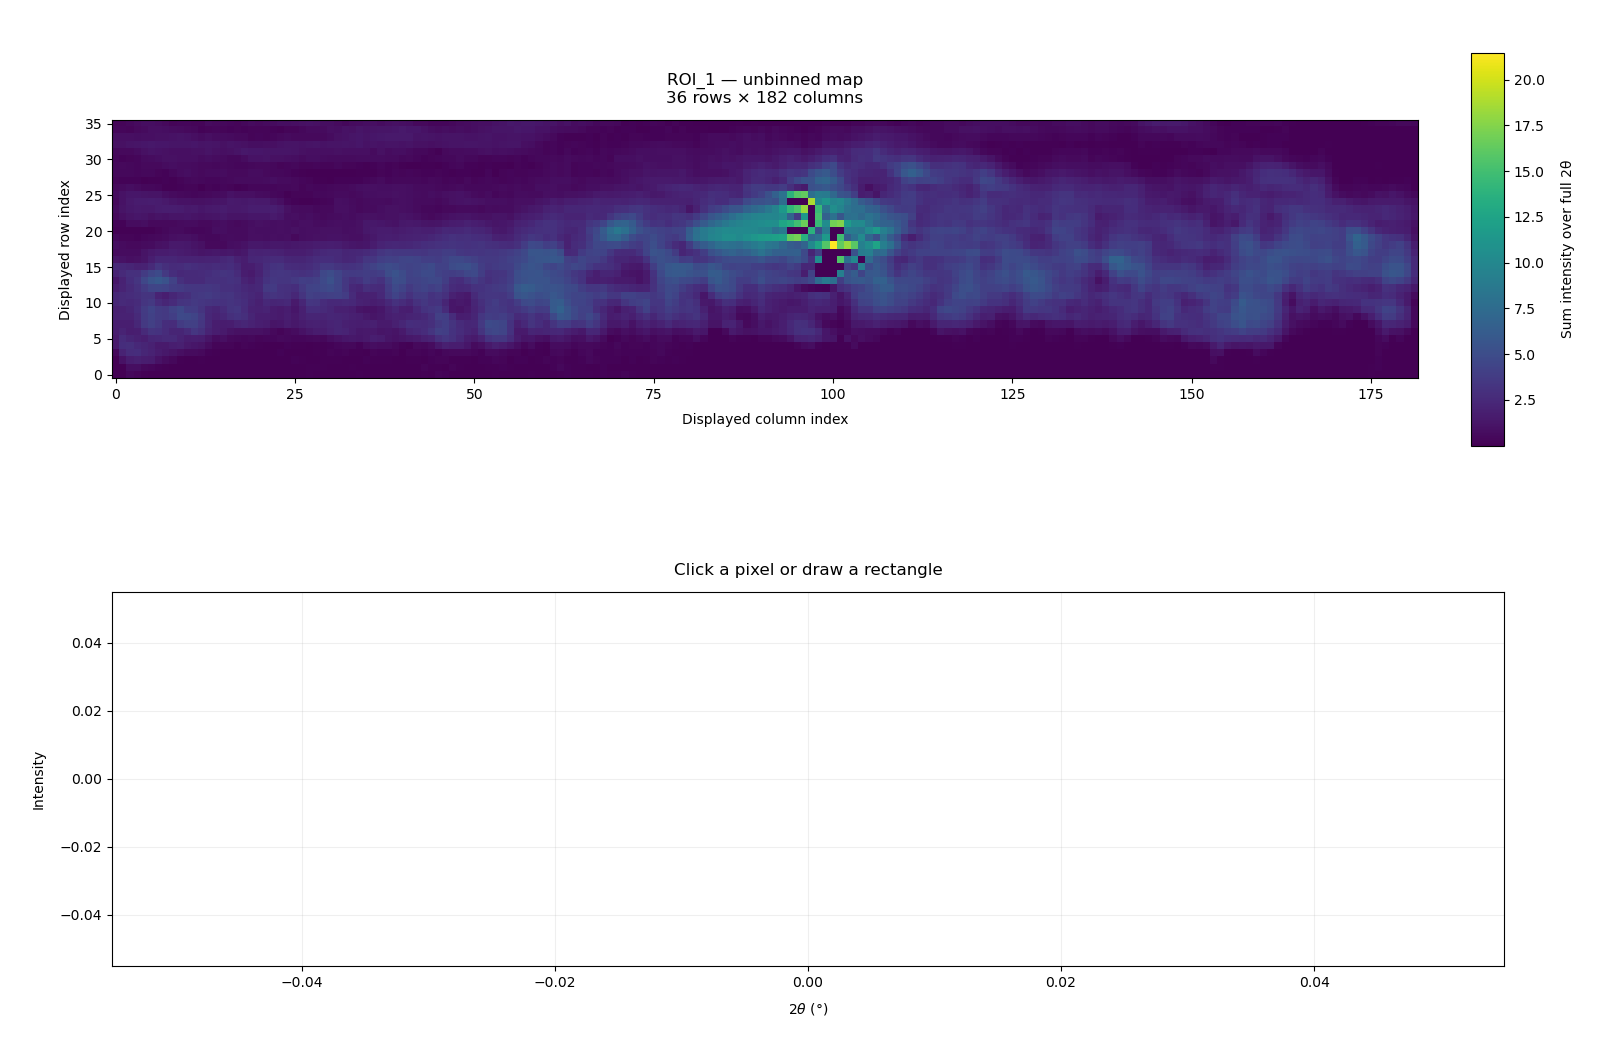

In [11]:
def launch_roi_explorer():
    """Interactive viewer for unbinned and binned ROI patterns."""

    files = discover_roi_files()

    # ==========================================================
    # Controls
    # ==========================================================

    roi_dropdown = Dropdown(
        options=[
            (file.name, index)
            for index, file in enumerate(files)
        ],
        value=0,
        description="ROI:",
        layout={"width": "500px"},
    )

    mode_dropdown = Dropdown(
        options=[
            ("Unbinned", "unbinned"),
            (
                f"Binned {BIN_SIZE}×{BIN_SIZE}",
                "binned",
            ),
        ],
        value="unbinned",
        description="Spatial:",
        layout={"width": "260px"},
    )

    selection_mode = ToggleButtons(
        options=[
            "Click pixel",
            "Draw rectangle",
        ],
        value="Click pixel",
        description="Select:",
    )

    rectangle_operation = Dropdown(
        options=[
            ("Mean pattern", "mean"),
            ("Summed pattern", "sum"),
        ],
        value="mean",
        description="Rectangle:",
        layout={"width": "260px"},
    )

    log_checkbox = Checkbox(
        value=False,
        description="Log y-scale",
        indent=False,
    )

    previous_button = Button(
        description="Previous",
        icon="arrow-left",
    )

    next_button = Button(
        description="Next",
        icon="arrow-right",
    )

    clear_button = Button(
        description="Clear selection",
        icon="eraser",
    )

    roi_info = HTML()
    selection_info = HTML()

    # ==========================================================
    # Current data
    # ==========================================================

    state = {
        "roi": None,
        "intensity": None,
        "summed": None,
    }

    # ==========================================================
    # Figure layout
    #
    # Row 1: ROI map + dedicated colorbar
    # Row 2: 1D diffraction pattern
    # ==========================================================

    plt.close("all")

    figure = plt.figure(
        figsize=(16, 10.5),
    )

    grid = figure.add_gridspec(
        2,
        2,
        width_ratios=[
            1.0,    # main plot width
            0.025,  # colorbar width
        ],
        height_ratios=[
            1.05,  # ROI map
            1.0,   # diffraction pattern
        ],
        left=0.07,
        right=0.94,
        bottom=0.08,
        top=0.95,
        hspace=0.38,
        wspace=0.08,
    )

    # ROI map at the top
    map_axis = figure.add_subplot(
        grid[0, 0]
    )

    # Dedicated colorbar beside the ROI map
    colorbar_axis = figure.add_subplot(
        grid[0, 1]
    )

    # 1D pattern across the full bottom row
    pattern_axis = figure.add_subplot(
        grid[1, :]
    )

    map_image = map_axis.imshow(
        np.zeros((2, 2)),
        cmap="viridis",
        origin="lower",
        aspect="equal",
        interpolation="nearest",
    )

    colorbar = figure.colorbar(
        map_image,
        cax=colorbar_axis,
    )

    colorbar.set_label(
        "Sum intensity over full 2θ",
        labelpad=12,
    )

    colorbar_axis.yaxis.set_label_position(
        "right"
    )

    colorbar_axis.yaxis.tick_right()

    pattern_line, = pattern_axis.plot(
        [],
        [],
        linewidth=1,
    )

    pattern_axis.set_xlabel(
        r"$2\theta$ (°)",
        labelpad=8,
    )

    pattern_axis.set_ylabel(
        "Intensity",
        labelpad=10,
    )

    pattern_axis.set_title(
        "Click a pixel or draw a rectangle",
        pad=12,
    )

    pattern_axis.grid(
        alpha=0.2
    )

    # ==========================================================
    # Map selection indicators
    # ==========================================================

    click_marker, = map_axis.plot(
        [],
        [],
        marker="o",
        markersize=8,
        markerfacecolor="none",
        markeredgecolor="red",
        markeredgewidth=2,
        linestyle="",
    )

    rectangle_patch = Rectangle(
        (0, 0),
        0,
        0,
        fill=False,
        edgecolor="red",
        linewidth=2,
    )

    rectangle_patch.set_visible(
        False
    )

    map_axis.add_patch(
        rectangle_patch
    )

    # ==========================================================
    # Update the 1D-pattern axes
    # ==========================================================

    def update_pattern_axes():

        pattern_axis.set_yscale(
            "log"
            if log_checkbox.value
            else "linear"
        )

        pattern_axis.relim()
        pattern_axis.autoscale_view()

        figure.canvas.draw_idle()

    # ==========================================================
    # Describe one displayed point
    # ==========================================================

    def point_description(row, column):

        ranges = source_ranges(
            state["roi"],
            mode_dropdown.value,
            row,
            column,
        )

        lr0, lr1, lc0, lc1 = (
            ranges["local"]
        )

        or0, or1, oc0, oc1 = (
            ranges["original"]
        )

        return (
            f"<b>Displayed point:</b> "
            f"row {row}, column {column}<br>"
            f"<b>Source local pixels:</b> "
            f"rows {lr0}–{lr1}, "
            f"columns {lc0}–{lc1}<br>"
            f"<b>Original-image pixels:</b> "
            f"rows {or0}–{or1}, "
            f"columns {oc0}–{oc1}"
        )

    # ==========================================================
    # Display one pixel pattern
    # ==========================================================

    def show_pixel(row, column):

        intensity = state["intensity"]

        if intensity is None:
            return

        _, height, width = intensity.shape

        if not (
            0 <= row < height
            and 0 <= column < width
        ):
            return

        pattern = intensity[
            :,
            row,
            column,
        ]

        pattern_line.set_data(
            state["roi"]["two_theta"],
            pattern,
        )

        click_marker.set_data(
            [column],
            [row],
        )

        rectangle_patch.set_visible(
            False
        )

        pattern_axis.set_title(
            f"Pattern at row {row}, column {column}",
            pad=12,
        )

        selection_info.value = (
            point_description(
                row,
                column,
            )
        )

        update_pattern_axes()

    # ==========================================================
    # Display the mean or sum inside a rectangle
    # ==========================================================

    def show_rectangle(r0, r1, c0, c1):

        block = state["intensity"][
            :,
            r0:r1 + 1,
            c0:c1 + 1,
        ]

        if rectangle_operation.value == "mean":

            finite_count = np.sum(
                np.isfinite(block),
                axis=(1, 2),
            )

            block_sum = np.nansum(
                block,
                axis=(1, 2),
            )

            pattern = np.full(
                block.shape[0],
                np.nan,
                dtype=np.float64,
            )

            np.divide(
                block_sum,
                finite_count,
                out=pattern,
                where=finite_count > 0,
            )

            operation_text = "Mean"

        else:

            pattern = np.nansum(
                block,
                axis=(1, 2),
            )

            operation_text = "Sum"

        pattern_line.set_data(
            state["roi"]["two_theta"],
            pattern,
        )

        click_marker.set_data(
            [],
            [],
        )

        rectangle_patch.set_xy(
            (
                c0 - 0.5,
                r0 - 0.5,
            )
        )

        rectangle_patch.set_width(
            c1 - c0 + 1
        )

        rectangle_patch.set_height(
            r1 - r0 + 1
        )

        rectangle_patch.set_visible(
            True
        )

        pattern_axis.set_title(
            f"{operation_text} pattern: "
            f"rows {r0}–{r1}, "
            f"columns {c0}–{c1}",
            pad=12,
        )

        selection_info.value = (
            f"<b>Displayed rectangle:</b> "
            f"rows {r0}–{r1}, "
            f"columns {c0}–{c1}<br>"
            f"<b>Number of displayed points:</b> "
            f"{(r1 - r0 + 1) * (c1 - c0 + 1)}"
        )

        update_pattern_axes()

    # ==========================================================
    # Convert rectangle selection to integer bounds
    # ==========================================================

    def rectangle_bounds(click, release):

        if (
            click.xdata is None
            or click.ydata is None
            or release.xdata is None
            or release.ydata is None
        ):
            return None

        height, width = (
            state["summed"].shape
        )

        c0 = max(
            0,
            int(
                np.floor(
                    min(
                        click.xdata,
                        release.xdata,
                    )
                )
            ),
        )

        c1 = min(
            width - 1,
            int(
                np.floor(
                    max(
                        click.xdata,
                        release.xdata,
                    )
                )
            ),
        )

        r0 = max(
            0,
            int(
                np.floor(
                    min(
                        click.ydata,
                        release.ydata,
                    )
                )
            ),
        )

        r1 = min(
            height - 1,
            int(
                np.floor(
                    max(
                        click.ydata,
                        release.ydata,
                    )
                )
            ),
        )

        return r0, r1, c0, c1

    # ==========================================================
    # Mouse callbacks
    # ==========================================================

    def on_map_click(event):

        if (
            selection_mode.value != "Click pixel"
            or event.inaxes is not map_axis
            or event.button != 1
            or event.xdata is None
            or event.ydata is None
        ):
            return

        row = int(
            round(event.ydata)
        )

        column = int(
            round(event.xdata)
        )

        show_pixel(
            row,
            column,
        )

    def on_rectangle(click, release):

        if (
            selection_mode.value
            != "Draw rectangle"
        ):
            return

        bounds = rectangle_bounds(
            click,
            release,
        )

        if bounds is not None:

            show_rectangle(
                *bounds
            )

    selector = RectangleSelector(
        map_axis,
        on_rectangle,
        useblit=True,
        button=[1],
        minspanx=0.5,
        minspany=0.5,
        spancoords="data",
        interactive=True,
    )

    # ==========================================================
    # Selection controls
    # ==========================================================

    def update_selection_mode(change=None):

        selector.set_active(
            selection_mode.value
            == "Draw rectangle"
        )

    def clear_selection(button=None):

        pattern_line.set_data(
            [],
            [],
        )

        click_marker.set_data(
            [],
            [],
        )

        rectangle_patch.set_visible(
            False
        )

        pattern_axis.set_title(
            "Click a pixel or draw a rectangle",
            pad=12,
        )

        selection_info.value = ""

        update_pattern_axes()

    # ==========================================================
    # Load the selected ROI
    # ==========================================================

    def load_current(change=None):

        roi = load_roi_file(
            files[
                roi_dropdown.value
            ]
        )

        intensity = spatial_intensity(
            roi,
            mode_dropdown.value,
        )

        summed = full_theta_sum(
            intensity
        )

        state.update(
            {
                "roi": roi,
                "intensity": intensity,
                "summed": summed,
            }
        )

        height, width = summed.shape

        extent = [
            -0.5,
            width - 0.5,
            -0.5,
            height - 0.5,
        ]

        map_image.set_data(
            summed
        )

        map_image.set_extent(
            extent
        )

        finite = summed[
            np.isfinite(summed)
        ]

        if finite.size:

            vmin = float(
                np.min(finite)
            )

            vmax = float(
                np.max(finite)
            )

            if vmax <= vmin:
                vmax = vmin + 1.0

            map_image.set_clim(
                vmin,
                vmax,
            )

        map_axis.set_xlim(
            -0.5,
            width - 0.5,
        )

        map_axis.set_ylim(
            -0.5,
            height - 0.5,
        )

        mode_text = (
            "unbinned"
            if mode_dropdown.value == "unbinned"
            else (
                f"{BIN_SIZE}×{BIN_SIZE} "
                f"{BIN_OPERATION}"
            )
        )

        map_axis.set_title(
            f"{roi['roi_name']} — {mode_text} map\n"
            f"{height} rows × {width} columns",
            pad=12,
        )

        map_axis.set_xlabel(
            "Displayed column index",
            labelpad=8,
        )

        map_axis.set_ylabel(
            "Displayed row index",
            labelpad=8,
        )

        r0, r1, c0, c1 = (
            roi["bounds"]
        )

        roi_info.value = (
            f"<b>ROI:</b> "
            f"{roi['roi_name']}<br>"
            f"<b>Original rows:</b> "
            f"{r0}–{r1}<br>"
            f"<b>Original columns:</b> "
            f"{c0}–{c1}<br>"
            f"<b>Displayed shape:</b> "
            f"{height} × {width}<br>"
            f"<b>Mode:</b> "
            f"{mode_text}"
        )

        clear_selection()

        colorbar.update_normal(
            map_image
        )

        figure.canvas.draw_idle()

    # ==========================================================
    # ROI navigation
    # ==========================================================

    def show_previous(button=None):

        roi_dropdown.value = (
            roi_dropdown.value - 1
        ) % len(files)

    def show_next(button=None):

        roi_dropdown.value = (
            roi_dropdown.value + 1
        ) % len(files)

    # ==========================================================
    # Connect callbacks
    # ==========================================================

    figure.canvas.mpl_connect(
        "button_press_event",
        on_map_click,
    )

    roi_dropdown.observe(
        load_current,
        names="value",
    )

    mode_dropdown.observe(
        load_current,
        names="value",
    )

    selection_mode.observe(
        update_selection_mode,
        names="value",
    )

    rectangle_operation.observe(
        lambda change: clear_selection(),
        names="value",
    )

    log_checkbox.observe(
        lambda change: update_pattern_axes(),
        names="value",
    )

    previous_button.on_click(
        show_previous
    )

    next_button.on_click(
        show_next
    )

    clear_button.on_click(
        clear_selection
    )

    # ==========================================================
    # Initial display
    # ==========================================================

    update_selection_mode()
    load_current()

    display(
        VBox(
            [
                HBox(
                    [
                        roi_dropdown,
                        mode_dropdown,
                    ]
                ),
                HBox(
                    [
                        previous_button,
                        next_button,
                        clear_button,
                    ]
                ),
                HBox(
                    [
                        selection_mode,
                        rectangle_operation,
                        log_checkbox,
                    ]
                ),
                roi_info,
                selection_info,
            ]
        )
    )

    return {
        "figure": figure,
        "state": state,
    }


roi_explorer = launch_roi_explorer()

## 2. Validate low-intensity points

Run either or both validator cells below.

### Interaction

- Click the histogram to set the threshold.
- The original and filtered maps use the same color scale.
- Invalid points are displayed in red.
- Click a point in the filtered map to inspect its original 1D pattern.
- The selected point is reported as valid or invalid at the current threshold.
- Press the save button only after the threshold looks appropriate.

### Important distinction

The unbinned and binned validators calculate their thresholds from different spatial data. A point can therefore be accepted in one representation and rejected in the other. The validated files are saved in separate folders and are independent.

In [12]:
def launch_validator(mode):
    """
    Launch the common validator for unbinned or binned data.
    """
    if mode not in {"unbinned", "binned"}:
        raise ValueError(
            "mode must be 'unbinned' or 'binned'."
        )

    files = discover_roi_files()

    (
        initial_threshold,
        log_min,
        log_max,
    ) = initial_threshold_for_mode(
        files,
        mode,
    )

    mode_label = (
        "Unbinned"
        if mode == "unbinned"
        else (
            f"Binned {BIN_SIZE}×{BIN_SIZE} "
            f"{BIN_OPERATION}"
        )
    )

    roi_dropdown = Dropdown(
        options=[
            (file.name, index)
            for index, file in enumerate(files)
        ],
        value=0,
        description="ROI:",
        layout={"width": "500px"},
    )

    threshold_slider = FloatLogSlider(
        value=initial_threshold,
        base=10,
        min=log_min,
        max=log_max,
        step=0.01,
        description="Threshold:",
        continuous_update=False,
        readout_format=".5e",
        layout={"width": "700px"},
    )

    log_checkbox = Checkbox(
        value=False,
        description="Log 1D pattern",
        indent=False,
    )

    previous_button = Button(
        description="Previous",
        icon="arrow-left",
    )

    next_button = Button(
        description="Next",
        icon="arrow-right",
    )

    save_button = Button(
        description=f"Save validated {mode} NPZs",
        button_style="success",
        icon="save",
    )

    roi_info = HTML()
    threshold_info = HTML()
    point_info = HTML()
    status = HTML()

    state = {
        "roi": None,
        "intensity": None,
        "summed": None,
        "invalid_mask": None,
        "selected_row": None,
        "selected_column": None,
    }

    original_cmap = plt.get_cmap(
        "viridis"
    ).copy()

    filtered_cmap = plt.get_cmap(
        "viridis"
    ).copy()
    filtered_cmap.set_bad(
        color="red"
    )

    plt.close("all")

    figure = plt.figure(
        figsize=(18, 13)
    )

    grid = figure.add_gridspec(
        3,
        3,
        width_ratios=[1.0, 1.0, 0.035],
        height_ratios=[1.0, 1.0, 1.15],
        hspace=0.25,
        wspace=0.22,
    )

    original_axis = figure.add_subplot(
        grid[0, 0:2]
    )
    filtered_axis = figure.add_subplot(
        grid[1, 0:2]
    )
    histogram_axis = figure.add_subplot(
        grid[2, 0]
    )
    pattern_axis = figure.add_subplot(
        grid[2, 1]
    )
    colorbar_axis = figure.add_subplot(
        grid[0:2, 2]
    )

    original_image = original_axis.imshow(
        np.zeros((2, 2)),
        cmap=original_cmap,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
    )

    filtered_image = filtered_axis.imshow(
        np.zeros((2, 2)),
        cmap=filtered_cmap,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
    )

    colorbar = figure.colorbar(
        filtered_image,
        cax=colorbar_axis,
    )

    colorbar.set_label(
        "Sum intensity over full 2θ"
    )

    for axis in (
        original_axis,
        filtered_axis,
    ):
        axis.set_xlabel(
            "Displayed column index"
        )
        axis.set_ylabel(
            "Displayed row index"
        )

    pattern_line, = pattern_axis.plot(
        [],
        [],
        linewidth=1.2,
    )

    pattern_axis.set_xlabel(
        r"$2\theta$ (°)"
    )
    pattern_axis.set_ylabel(
        "Intensity"
    )
    pattern_axis.grid(
        alpha=0.2
    )

    original_marker, = original_axis.plot(
        [],
        [],
        marker="o",
        markersize=9,
        markerfacecolor="none",
        markeredgecolor="white",
        markeredgewidth=1.7,
        linestyle="",
    )

    filtered_marker, = filtered_axis.plot(
        [],
        [],
        marker="o",
        markersize=9,
        markerfacecolor="none",
        markeredgecolor="white",
        markeredgewidth=1.7,
        linestyle="",
    )

    figure.subplots_adjust(
        left=0.06,
        right=0.94,
        bottom=0.06,
        top=0.96,
    )

    def update_pattern_axes():
        pattern_axis.set_yscale(
            "log"
            if log_checkbox.value
            else "linear"
        )
        pattern_axis.relim()
        pattern_axis.autoscale_view()
        figure.canvas.draw_idle()

    def show_pattern(row, column):
        intensity = state["intensity"]
        invalid_mask = state["invalid_mask"]

        if (
            intensity is None
            or invalid_mask is None
        ):
            return

        _, height, width = intensity.shape

        if not (
            0 <= row < height
            and 0 <= column < width
        ):
            return

        state["selected_row"] = row
        state["selected_column"] = column

        pattern = intensity[
            :,
            row,
            column,
        ]

        is_invalid = bool(
            invalid_mask[row, column]
        )

        pattern_line.set_data(
            state["roi"]["two_theta"],
            pattern,
        )
        pattern_line.set_color(
            "red"
            if is_invalid
            else "tab:blue"
        )

        original_marker.set_data(
            [column],
            [row],
        )
        filtered_marker.set_data(
            [column],
            [row],
        )

        ranges = source_ranges(
            state["roi"],
            mode,
            row,
            column,
        )

        lr0, lr1, lc0, lc1 = (
            ranges["local"]
        )
        or0, or1, oc0, oc1 = (
            ranges["original"]
        )

        status_text = (
            "INVALID"
            if is_invalid
            else "VALID"
        )

        pattern_axis.set_title(
            f"{mode_label} pattern — {status_text}\n"
            f"row={row}, column={column}",
            pad=10,
        )

        point_info.value = (
            f"<b>Displayed point:</b> "
            f"row {row}, column {column}<br>"
            f"<b>Source local pixels:</b> "
            f"rows {lr0}–{lr1}, "
            f"columns {lc0}–{lc1}<br>"
            f"<b>Original-image pixels:</b> "
            f"rows {or0}–{or1}, "
            f"columns {oc0}–{oc1}<br>"
            f"<b>Full-2θ sum:</b> "
            f"{state['summed'][row, column]:.6e}<br>"
            f"<b>Threshold:</b> "
            f"{threshold_slider.value:.6e}<br>"
            f"<b>Status:</b> "
            f"<span style='color:"
            f"{'red' if is_invalid else 'blue'};'>"
            f"{status_text}</span>"
        )

        update_pattern_axes()

    def update_threshold(change=None):
        summed = state["summed"]

        if summed is None:
            return

        threshold = float(
            threshold_slider.value
        )

        invalid_mask = (
            ~np.isfinite(summed)
            | (summed <= threshold)
        )

        state["invalid_mask"] = (
            invalid_mask
        )

        filtered_map = summed.copy()
        filtered_map[invalid_mask] = np.nan

        height, width = summed.shape
        extent = [
            -0.5,
            width - 0.5,
            -0.5,
            height - 0.5,
        ]

        original_image.set_data(
            summed
        )
        original_image.set_extent(
            extent
        )

        filtered_image.set_data(
            filtered_map
        )
        filtered_image.set_extent(
            extent
        )

        finite = summed[
            np.isfinite(summed)
        ]

        if finite.size:
            vmin = float(np.min(finite))
            vmax = float(np.max(finite))
            if vmax <= vmin:
                vmax = vmin + 1.0
        else:
            vmin = 0.0
            vmax = 1.0

        original_image.set_clim(
            vmin,
            vmax,
        )
        filtered_image.set_clim(
            vmin,
            vmax,
        )
        colorbar.update_normal(
            filtered_image
        )

        for axis in (
            original_axis,
            filtered_axis,
        ):
            axis.set_xlim(
                -0.5,
                width - 0.5,
            )
            axis.set_ylim(
                -0.5,
                height - 0.5,
            )

        histogram_axis.clear()

        positive = summed[
            np.isfinite(summed)
            & (summed > 0)
        ]

        if positive.size:
            positive_min = float(
                np.min(positive)
            )
            positive_max = float(
                np.max(positive)
            )

            if positive_max > positive_min:
                bins = np.logspace(
                    np.log10(positive_min),
                    np.log10(positive_max),
                    100,
                )
                histogram_axis.hist(
                    positive,
                    bins=bins,
                    edgecolor="none",
                )
                histogram_axis.set_xscale(
                    "log"
                )
            else:
                histogram_axis.hist(
                    positive,
                    bins=10,
                )

            histogram_axis.axvline(
                threshold,
                linestyle="--",
                linewidth=2.5,
                label=(
                    f"threshold = "
                    f"{threshold:.5e}"
                ),
            )
            histogram_axis.legend(
                loc="upper left"
            )

        histogram_axis.set_title(
            f"{mode_label} pixel-sum distribution\n"
            "Left-click to set threshold",
            pad=10,
        )
        histogram_axis.set_xlabel(
            "Sum intensity over full 2θ"
        )
        histogram_axis.set_ylabel(
            "Number of points"
        )
        histogram_axis.grid(
            alpha=0.2
        )

        valid_count = int(
            np.sum(~invalid_mask)
        )
        invalid_count = int(
            np.sum(invalid_mask)
        )
        total_count = int(
            invalid_mask.size
        )

        threshold_info.value = (
            f"<b>Threshold:</b> "
            f"{threshold:.6e}<br>"
            f"<b>Valid points:</b> "
            f"{valid_count} / {total_count}<br>"
            f"<b>Invalid points:</b> "
            f"{invalid_count} / {total_count} "
            f"({100*invalid_count/total_count:.2f}%)"
        )

        if (
            state["selected_row"] is not None
            and state["selected_column"] is not None
        ):
            show_pattern(
                state["selected_row"],
                state["selected_column"],
            )
        else:
            figure.canvas.draw_idle()

    def on_figure_click(event):
        if (
            event.button != 1
            or event.xdata is None
            or event.ydata is None
        ):
            return

        if event.inaxes is histogram_axis:
            clicked = float(
                event.xdata
            )

            if (
                np.isfinite(clicked)
                and clicked > 0
            ):
                threshold_slider.value = float(
                    np.clip(
                        clicked,
                        10.0 ** log_min,
                        10.0 ** log_max,
                    )
                )

        elif event.inaxes is filtered_axis:
            row = int(
                round(event.ydata)
            )
            column = int(
                round(event.xdata)
            )
            show_pattern(
                row,
                column,
            )

    def load_current(change=None):
        roi = load_roi_file(
            files[roi_dropdown.value]
        )

        intensity = spatial_intensity(
            roi,
            mode,
        )

        state.update(
            {
                "roi": roi,
                "intensity": intensity,
                "summed": full_theta_sum(
                    intensity
                ),
                "invalid_mask": None,
                "selected_row": None,
                "selected_column": None,
            }
        )

        height, width = (
            state["summed"].shape
        )
        r0, r1, c0, c1 = (
            roi["bounds"]
        )

        original_axis.set_title(
            f"{roi['roi_name']} — original {mode_label}\n"
            f"{height} rows × {width} columns",
            pad=8,
        )

        filtered_axis.set_title(
            f"{roi['roi_name']} — filtered {mode_label}\n"
            f"Original rows {r0}–{r1}, "
            f"columns {c0}–{c1}",
            pad=8,
        )

        roi_info.value = (
            f"<b>ROI:</b> {roi['roi_name']}<br>"
            f"<b>Original-image rows:</b> "
            f"{r0}–{r1}<br>"
            f"<b>Original-image columns:</b> "
            f"{c0}–{c1}<br>"
            f"<b>Displayed shape:</b> "
            f"{height} × {width}<br>"
            f"<b>Mode:</b> {mode_label}"
        )

        pattern_line.set_data(
            [],
            [],
        )
        original_marker.set_data(
            [],
            [],
        )
        filtered_marker.set_data(
            [],
            [],
        )
        pattern_axis.set_title(
            "Click a point in the filtered map",
            pad=10,
        )
        point_info.value = ""

        update_threshold()

    def save_all(button=None):
        threshold = float(
            threshold_slider.value
        )

        save_button.disabled = True
        status.value = (
            f"<i>Saving validated {mode} files...</i>"
        )

        try:
            summary = save_validated_files(
                files,
                mode,
                threshold,
            )

            valid_total = sum(
                item["valid"]
                for item in summary
            )
            invalid_total = sum(
                item["invalid"]
                for item in summary
            )

            status.value = (
                '<span style="color:green;">'
                f"Saved {len(summary)} validated "
                f"{mode} NPZ files.<br>"
                f"<b>Threshold:</b> "
                f"{threshold:.6e}<br>"
                f"<b>Total valid:</b> "
                f"{valid_total}<br>"
                f"<b>Total invalid:</b> "
                f"{invalid_total}<br>"
                f"<b>Folder:</b><br>"
                f"{VALIDATED_FOLDERS[mode]}"
                "</span>"
            )

        except Exception as error:
            status.value = (
                '<span style="color:red;">'
                f"Saving failed: {error}"
                "</span>"
            )

        finally:
            save_button.disabled = False

    def show_previous(button=None):
        roi_dropdown.value = (
            roi_dropdown.value - 1
        ) % len(files)

    def show_next(button=None):
        roi_dropdown.value = (
            roi_dropdown.value + 1
        ) % len(files)

    figure.canvas.mpl_connect(
        "button_press_event",
        on_figure_click,
    )

    roi_dropdown.observe(
        load_current,
        names="value",
    )
    threshold_slider.observe(
        update_threshold,
        names="value",
    )
    log_checkbox.observe(
        lambda change: update_pattern_axes(),
        names="value",
    )

    previous_button.on_click(
        show_previous
    )
    next_button.on_click(
        show_next
    )
    save_button.on_click(
        save_all
    )

    load_current()

    display(
        VBox(
            [
                roi_dropdown,
                HBox(
                    [
                        previous_button,
                        next_button,
                        log_checkbox,
                    ]
                ),
                threshold_slider,
                HTML(
                    "<b>Tip:</b> click the histogram "
                    "to set the threshold and click "
                    "the filtered map to inspect a pattern."
                ),
                save_button,
                roi_info,
                threshold_info,
                point_info,
                status,
            ]
        )
    )

    return {
        "figure": figure,
        "state": state,
        "threshold_slider": threshold_slider,
    }

### 2A. Unbinned validation

This applies the threshold to every original scanning pixel. Press **Save validated unbinned NPZs** after choosing the threshold.

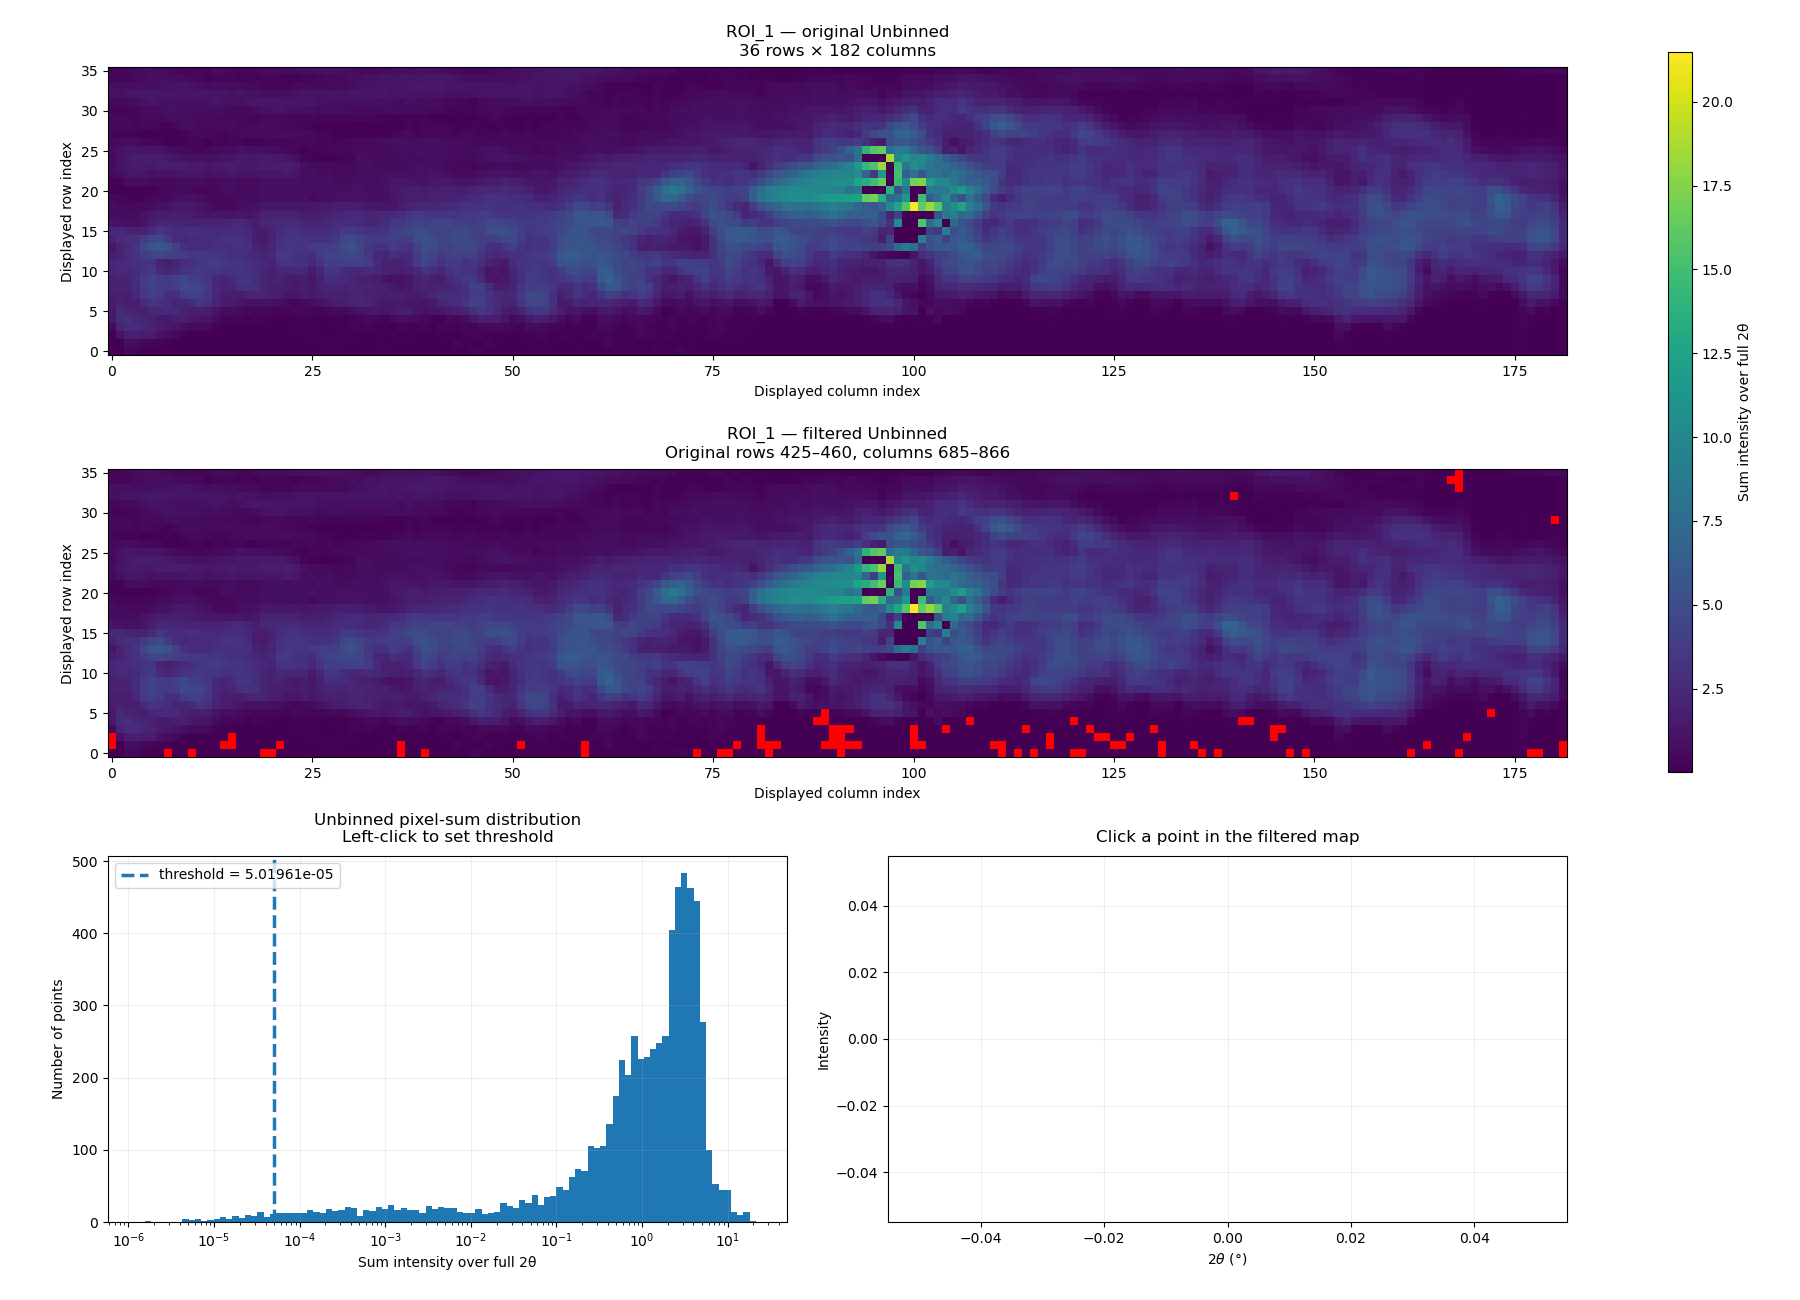

In [13]:
unbinned_validator = launch_validator("unbinned")

### 2B. Binned validation

This first combines every spatial block using `BIN_SIZE` and `BIN_OPERATION`, then applies the threshold to the resulting binned patterns. Press **Save validated binned NPZs** after choosing the threshold.

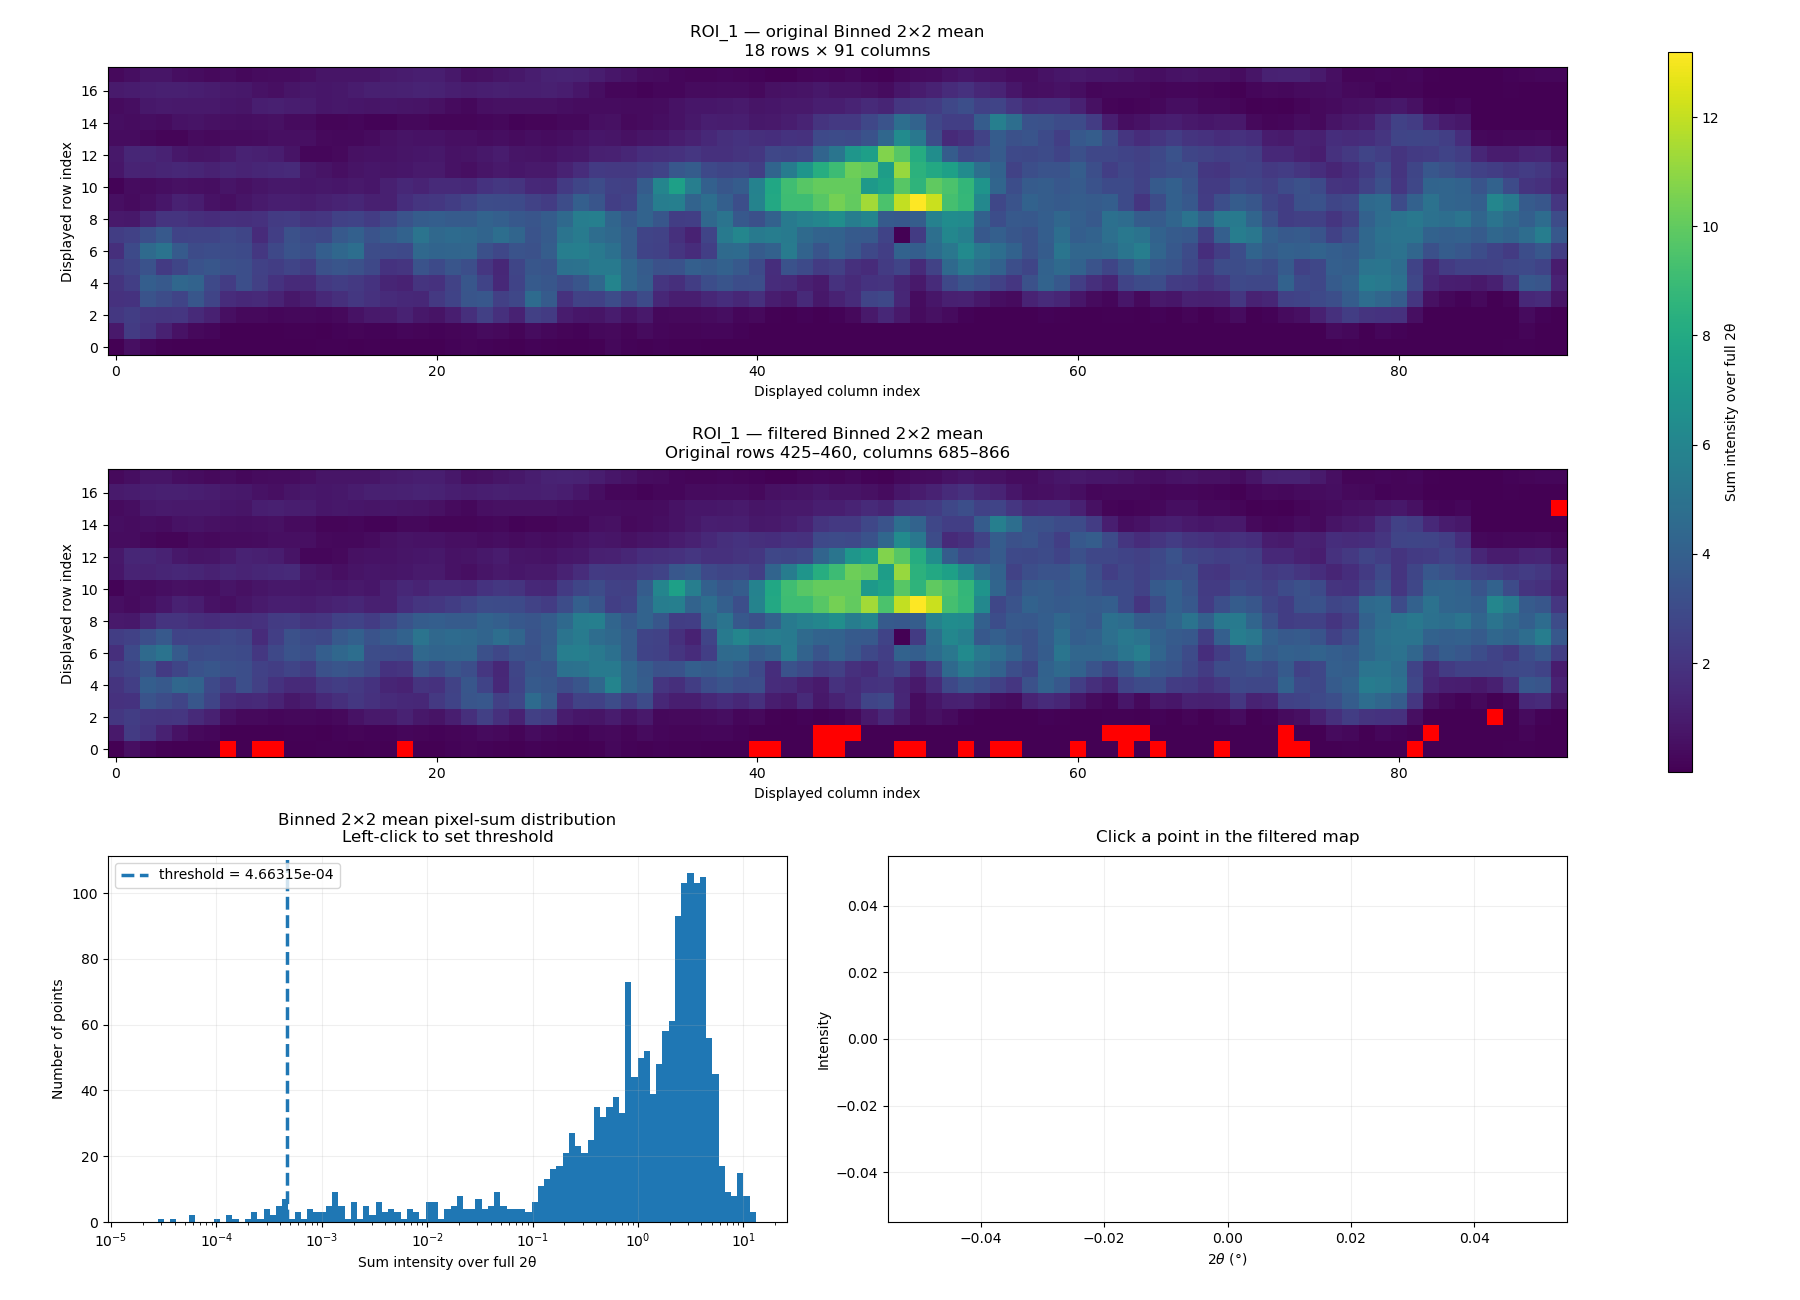

In [14]:
binned_validator = launch_validator("binned")

## 3. Export valid patterns to `.xy`

Each exported file contains exactly two columns and no header:

```text
2theta    intensity
```

The filename stores the displayed row, column, and full-grid linear index:

```text
prefix_raw_r000_c000_idx00000.xy
prefix_bin2x2_r000_c000_idx00000.xy
```

Invalid points are not written. Consequently, missing `idx` values identify positions rejected by the threshold.

Run only the export cell corresponding to the validated dataset you need.

In [ ]:
# Export valid unbinned patterns
export_valid_xy("unbinned")

In [ ]:
# Export valid binned patterns
export_valid_xy("binned")

## 4. Average filtered patterns separately inside each ROI

The following cells calculate one average pattern for each ROI independently:

\[
\bar I_{\mathrm{ROI}}(2\theta)
=
\frac{1}{N_{\mathrm{valid}}}
\sum_{p\in\mathrm{valid\ ROI\ points}}
I_p(2\theta).
\]

Invalid points do not contribute. Each ROI average is plotted and saved as a separate headerless `.xy` file.

The unbinned and binned averages can differ because their thresholds are applied to different spatial representations.

In [ ]:
# Average valid unbinned patterns separately for each ROI
unbinned_roi_averages = average_valid_patterns_per_roi("unbinned")

In [ ]:
# Average valid binned patterns separately for each ROI
binned_roi_averages = average_valid_patterns_per_roi("binned")

## Recommended execution order

1. Run **Configuration and imports**.
2. Run **Reusable functions**.
3. Use the ROI explorer if needed.
4. Run the unbinned validator and/or binned validator.
5. Select the threshold and save the validated NPZ files.
6. Export the valid `.xy` patterns.
7. Generate the per-ROI averages.

When changing `ROI_FOLDER`, `BIN_SIZE`, or `BIN_OPERATION`, restart the kernel and rerun from the configuration cell so that every output folder and interactive control uses the same settings.